# 🎙️ Module 5 — Speech Signal Exploratory Analysis

**Project:** Speech Emotion Recognition System  
**Dataset:** RAVDESS (1,440 preprocessed audio clips)  
**Goal:** Deep visual and statistical exploration of speech signals across all 8 emotion classes.

---

### What We Analyse
| Section | Analysis |
|---|---|
| 5.1 | Setup & Load Preprocessed Data |
| 5.2 | Waveform Visualisation per Emotion |
| 5.3 | Amplitude Envelope Analysis |
| 5.4 | Audio Duration & RMS Statistics |
| 5.5 | Frequency Domain — FFT Analysis |
| 5.6 | Mel Spectrogram Gallery (all 8 emotions) |
| 5.7 | Short-Time Fourier Transform (STFT) Spectrograms |
| 5.8 | Chromagram Visualisation |
| 5.9 | Zero Crossing Rate Comparison |
| 5.10 | Spectral Centroid & Bandwidth |
| 5.11 | Emotion-wise Statistical Summary Dashboard |

## 5.1 — Setup & Load Preprocessed Data

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.fft import rfft, rfftfreq
from scipy.signal import welch
warnings.filterwarnings('ignore')

# ── Global plot theme ──────────────────────────────────────────────────────
DARK_BG   = '#0d0d1a'
PANEL_BG  = '#12122a'
CARD_BG   = '#1a1a3e'
TEXT_CLR  = '#e2e8f0'
GRID_CLR  = '#252545'

plt.rcParams.update({
    'figure.facecolor' : DARK_BG,
    'axes.facecolor'   : PANEL_BG,
    'axes.labelcolor'  : TEXT_CLR,
    'axes.edgecolor'   : '#30305a',
    'text.color'       : TEXT_CLR,
    'xtick.color'      : '#9090b0',
    'ytick.color'      : '#9090b0',
    'grid.color'       : GRID_CLR,
    'font.size'        : 10,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 10,
})
sns.set_style('darkgrid')

# ── Paths ──────────────────────────────────────────────────────────────────
BASE        = os.path.dirname(os.path.abspath('__file__'))
DATA_PROC   = os.path.join(BASE, '..', 'data', 'processed')
FEATURES    = os.path.join(BASE, '..', 'features')
REPORTS     = os.path.join(BASE, '..', 'reports')
WAVREPORT   = os.path.join(REPORTS, 'waveforms')
SPECREP     = os.path.join(REPORTS, 'spectrograms')
os.makedirs(WAVREPORT, exist_ok=True)
os.makedirs(SPECREP,   exist_ok=True)

# ── Load preprocessed arrays ──────────────────────────────────────────────
X   = np.load(os.path.join(DATA_PROC, 'X_audio.npy'))   # (1440, 66150)
y   = np.load(os.path.join(DATA_PROC, 'y_labels.npy'))  # (1440,)
df  = pd.read_csv(os.path.join(FEATURES, 'dataset_metadata.csv'))

with open(os.path.join(DATA_PROC, 'preprocessing_config.json')) as f:
    cfg = json.load(f)

SR       = cfg['target_sr']       # 22050
DURATION = cfg['target_duration'] # 3.0
SAMPLES  = cfg['target_samples']  # 66150
EMOTIONS = cfg['emotion_classes'] # 8 emotions
TIME_AX  = np.linspace(0, DURATION, SAMPLES)

# ── Emotion colour palette ─────────────────────────────────────────────────
ECOLORS = {
    'neutral'  : '#94a3b8',
    'calm'     : '#22d3ee',
    'happy'    : '#fbbf24',
    'sad'      : '#60a5fa',
    'angry'    : '#f87171',
    'fearful'  : '#c084fc',
    'disgust'  : '#4ade80',
    'surprised': '#fb923c'
}

def get_sample(emotion, idx=0):
    """Return signal and metadata for the idx-th clip of a given emotion."""
    label_id = EMOTIONS.index(emotion)
    mask     = np.where(y == label_id)[0]
    row      = df[df['emotion'] == emotion].iloc[idx]
    return X[mask[idx]], row

print('✅ Data loaded successfully!')
print(f'   X shape  : {X.shape}  (clips × samples)')
print(f'   y shape  : {y.shape}')
print(f'   SR       : {SR} Hz | Duration: {DURATION}s | Samples: {SAMPLES:,}')
print(f'   Emotions : {EMOTIONS}')

✅ Data loaded successfully!
   X shape  : (1440, 66150)  (clips × samples)
   y shape  : (1440,)
   SR       : 22050 Hz | Duration: 3.0s | Samples: 66,150
   Emotions : ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']


## 5.2 — Waveform Gallery: All 8 Emotions

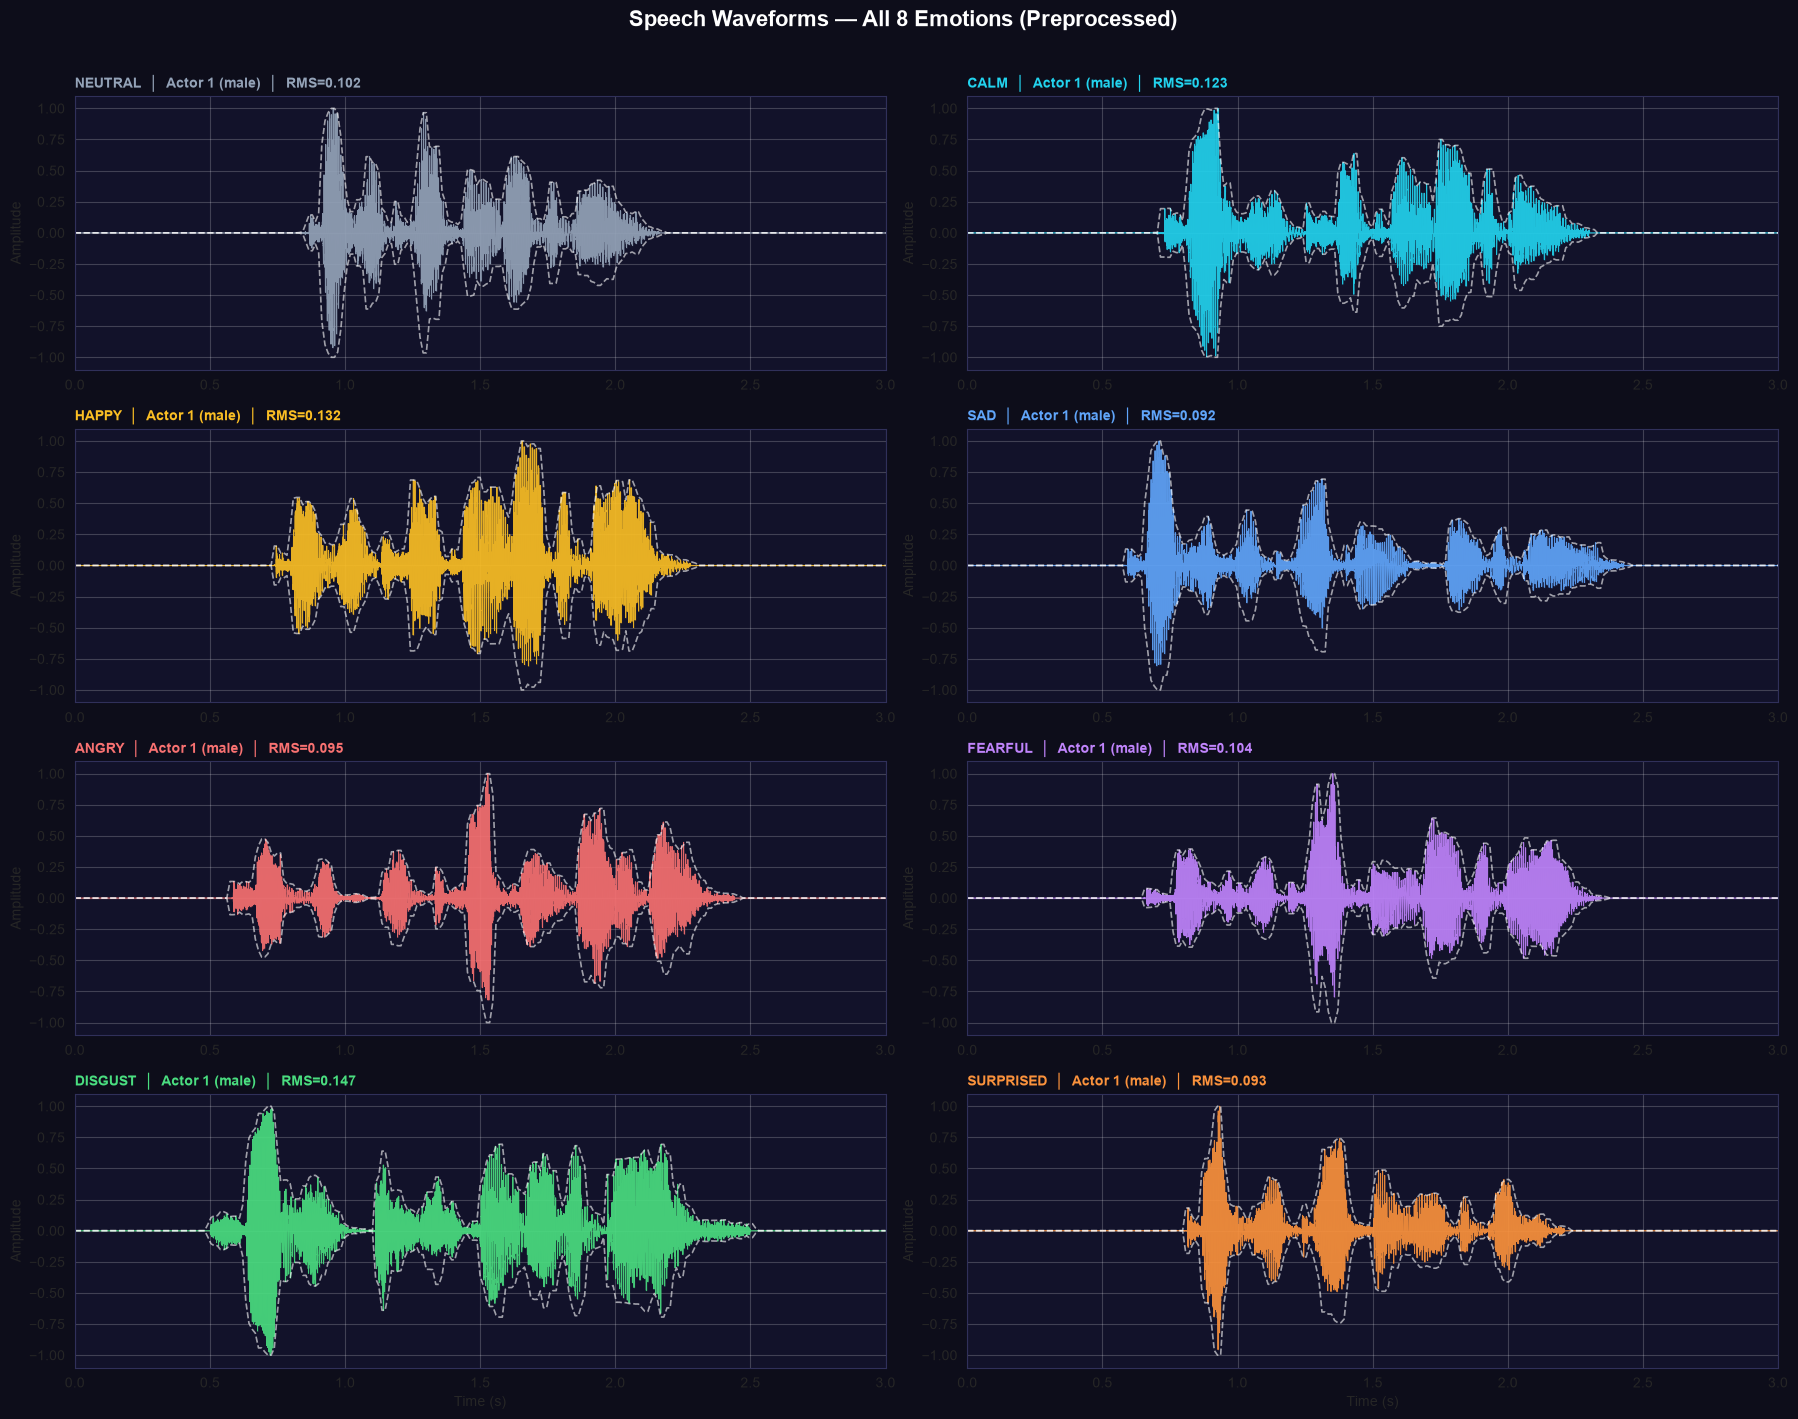

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\waveforms\waveform_gallery_all_emotions.png


In [2]:
fig, axes = plt.subplots(4, 2, figsize=(18, 14))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Speech Waveforms — All 8 Emotions (Preprocessed)',
             fontsize=16, fontweight='bold', color='white', y=1.01)

for ax, emotion in zip(axes.flat, EMOTIONS):
    sig, row = get_sample(emotion)
    color    = ECOLORS[emotion]
    ax.set_facecolor(PANEL_BG)

    ax.plot(TIME_AX, sig, color=color, linewidth=0.7, alpha=0.9)
    ax.fill_between(TIME_AX, sig, alpha=0.12, color=color)

    # Amplitude envelope
    frame_len = 512
    hop       = 256
    envelope  = np.array([
        np.max(np.abs(sig[i:i+frame_len]))
        for i in range(0, SAMPLES - frame_len, hop)
    ])
    env_t = np.linspace(0, DURATION, len(envelope))
    ax.plot(env_t,  envelope, color='white', linewidth=1.2, alpha=0.6, linestyle='--')
    ax.plot(env_t, -envelope, color='white', linewidth=1.2, alpha=0.6, linestyle='--')

    rms = float(np.sqrt(np.mean(sig**2)))
    ax.set_title(f'{emotion.upper()}  │  Actor {row["actor"]} ({row["gender"]})  │  RMS={rms:.3f}',
                 color=color, fontsize=10, loc='left', fontweight='bold')
    ax.set_xlim([0, DURATION])
    ax.set_ylim([-1.1, 1.1])
    ax.set_ylabel('Amplitude')
    ax.grid(alpha=0.2)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30305a')

axes[-1, 0].set_xlabel('Time (s)')
axes[-1, 1].set_xlabel('Time (s)')
plt.tight_layout()
path = os.path.join(WAVREPORT, 'waveform_gallery_all_emotions.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

## 5.3 — Amplitude Envelope Comparison (Multiple Clips per Emotion)

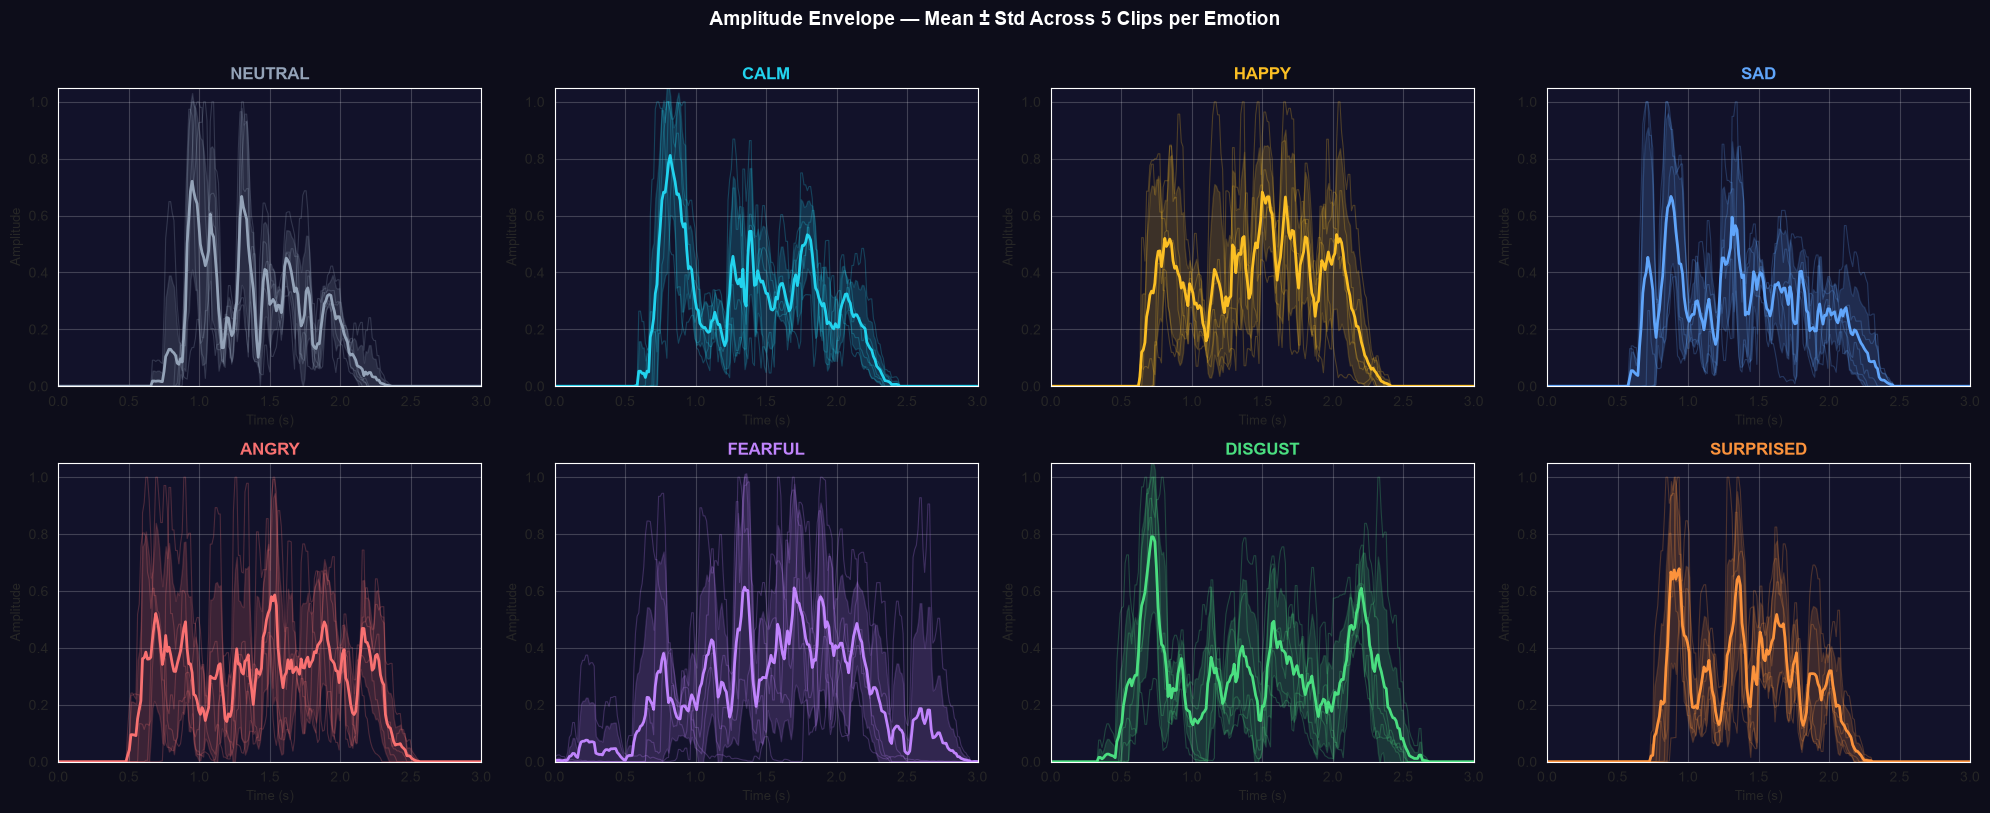

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\waveforms\amplitude_envelope_per_emotion.png


In [3]:
def compute_envelope(signal, frame_len=512, hop=256):
    env = [np.max(np.abs(signal[i:i+frame_len]))
           for i in range(0, len(signal)-frame_len, hop)]
    return np.array(env)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Amplitude Envelope — Mean ± Std Across 5 Clips per Emotion',
             fontsize=14, fontweight='bold', color='white', y=1.01)

N_CLIPS = 5
for ax, emotion in zip(axes.flat, EMOTIONS):
    color    = ECOLORS[emotion]
    label_id = EMOTIONS.index(emotion)
    indices  = np.where(y == label_id)[0][:N_CLIPS]

    envs = np.array([compute_envelope(X[i]) for i in indices])
    t_e  = np.linspace(0, DURATION, envs.shape[1])

    mean_env = envs.mean(axis=0)
    std_env  = envs.std(axis=0)

    ax.set_facecolor(PANEL_BG)
    for env in envs:
        ax.plot(t_e, env, color=color, alpha=0.25, linewidth=0.8)
    ax.plot(t_e, mean_env, color=color, linewidth=2.0, label='Mean envelope')
    ax.fill_between(t_e, mean_env - std_env, mean_env + std_env,
                    color=color, alpha=0.18, label='±1 std')
    ax.set_title(emotion.upper(), color=color, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.set_xlim([0, DURATION])
    ax.grid(alpha=0.2)
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.set_ylabel('Amplitude', fontsize=9)

plt.tight_layout()
path = os.path.join(WAVREPORT, 'amplitude_envelope_per_emotion.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

## 5.4 — Audio Duration & RMS Energy Statistics

⚡ RMS Energy Statistics per Emotion:
           count  rms_mean  rms_std  rms_min  rms_max
emotion                                              
neutral       96    0.1123   0.0236   0.0645   0.1786
calm         192    0.1261   0.0278   0.0710   0.1992
happy        192    0.1162   0.0237   0.0745   0.1805
sad          192    0.1168   0.0251   0.0470   0.1800
angry        192    0.1117   0.0245   0.0587   0.1835
fearful      192    0.1154   0.0223   0.0635   0.1760
disgust      192    0.1144   0.0269   0.0596   0.1886
surprised    192    0.1164   0.0237   0.0576   0.1979


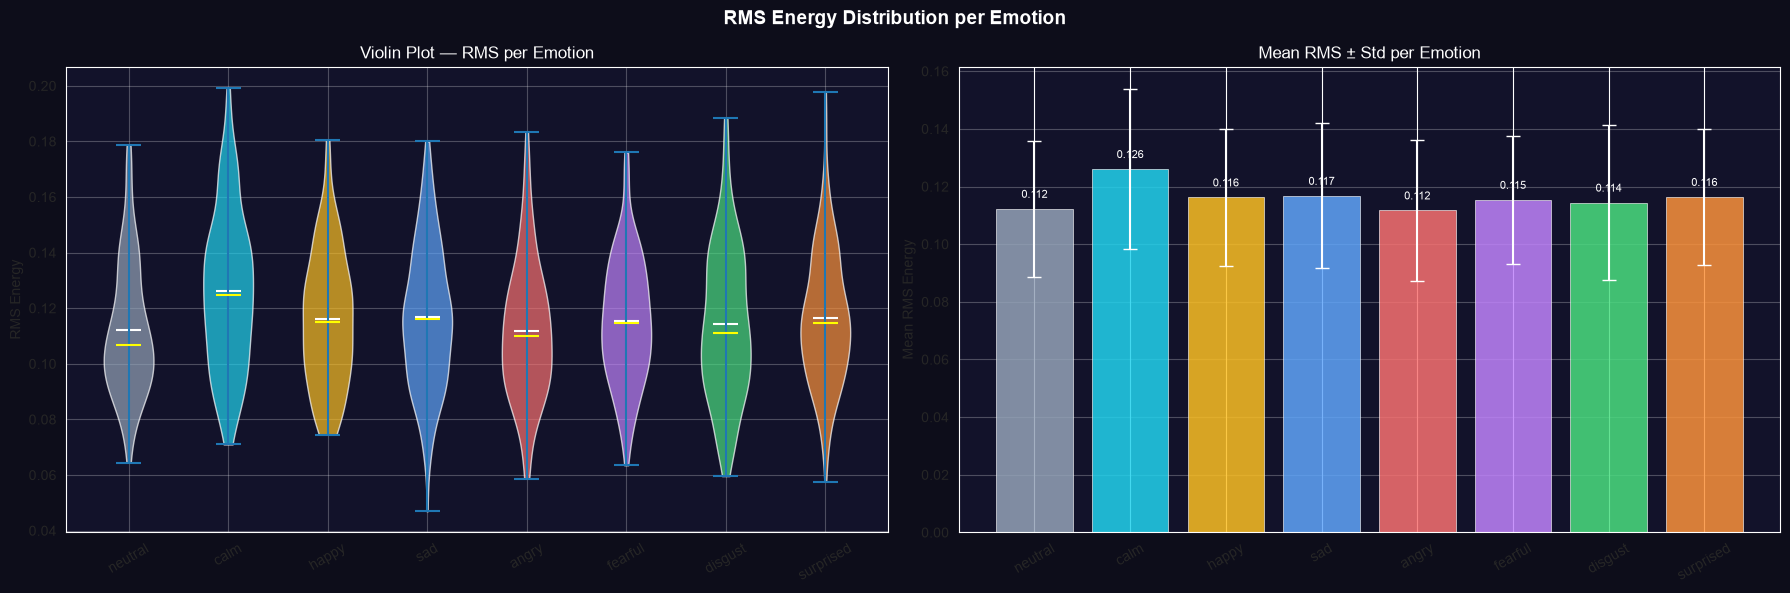

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\waveforms\rms_energy_per_emotion.png


In [4]:
# Compute RMS energy per clip
rms_all = np.sqrt(np.mean(X**2, axis=1))            # shape (1440,)
emotion_labels = np.array([EMOTIONS[i] for i in y])

stats_rows = []
for emotion in EMOTIONS:
    mask = emotion_labels == emotion
    rms_e = rms_all[mask]
    stats_rows.append({
        'emotion'  : emotion,
        'count'    : int(mask.sum()),
        'rms_mean' : float(rms_e.mean()),
        'rms_std'  : float(rms_e.std()),
        'rms_min'  : float(rms_e.min()),
        'rms_max'  : float(rms_e.max()),
    })
stats_df = pd.DataFrame(stats_rows).set_index('emotion')

print('⚡ RMS Energy Statistics per Emotion:')
print(stats_df.round(4).to_string())

# ── Violin plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('RMS Energy Distribution per Emotion', fontsize=14,
             fontweight='bold', color='white')

# Violin
ax1 = axes[0]
ax1.set_facecolor(PANEL_BG)
rms_by_em = [rms_all[emotion_labels == e] for e in EMOTIONS]
vp = ax1.violinplot(rms_by_em, positions=range(len(EMOTIONS)),
                    showmeans=True, showmedians=True)
for i, (body, em) in enumerate(zip(vp['bodies'], EMOTIONS)):
    body.set_facecolor(ECOLORS[em])
    body.set_alpha(0.7)
vp['cmeans'].set_color('white')
vp['cmedians'].set_color('yellow')
ax1.set_xticks(range(len(EMOTIONS)))
ax1.set_xticklabels(EMOTIONS, rotation=30)
ax1.set_ylabel('RMS Energy')
ax1.set_title('Violin Plot — RMS per Emotion', color='white')
ax1.grid(alpha=0.25)

# Bar + error bar
ax2 = axes[1]
ax2.set_facecolor(PANEL_BG)
x  = np.arange(len(EMOTIONS))
colors_ = [ECOLORS[e] for e in EMOTIONS]
bars = ax2.bar(x, stats_df['rms_mean'].values, color=colors_,
               yerr=stats_df['rms_std'].values,
               capsize=5, error_kw={'ecolor': 'white', 'linewidth': 1.5},
               alpha=0.85, edgecolor='white', linewidth=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(EMOTIONS, rotation=30)
ax2.set_ylabel('Mean RMS Energy')
ax2.set_title('Mean RMS ± Std per Emotion', color='white')
ax2.grid(axis='y', alpha=0.25)
for bar, val in zip(bars, stats_df['rms_mean'].values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='white')

plt.tight_layout()
path = os.path.join(WAVREPORT, 'rms_energy_per_emotion.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

## 5.5 — Frequency Domain Analysis (FFT)

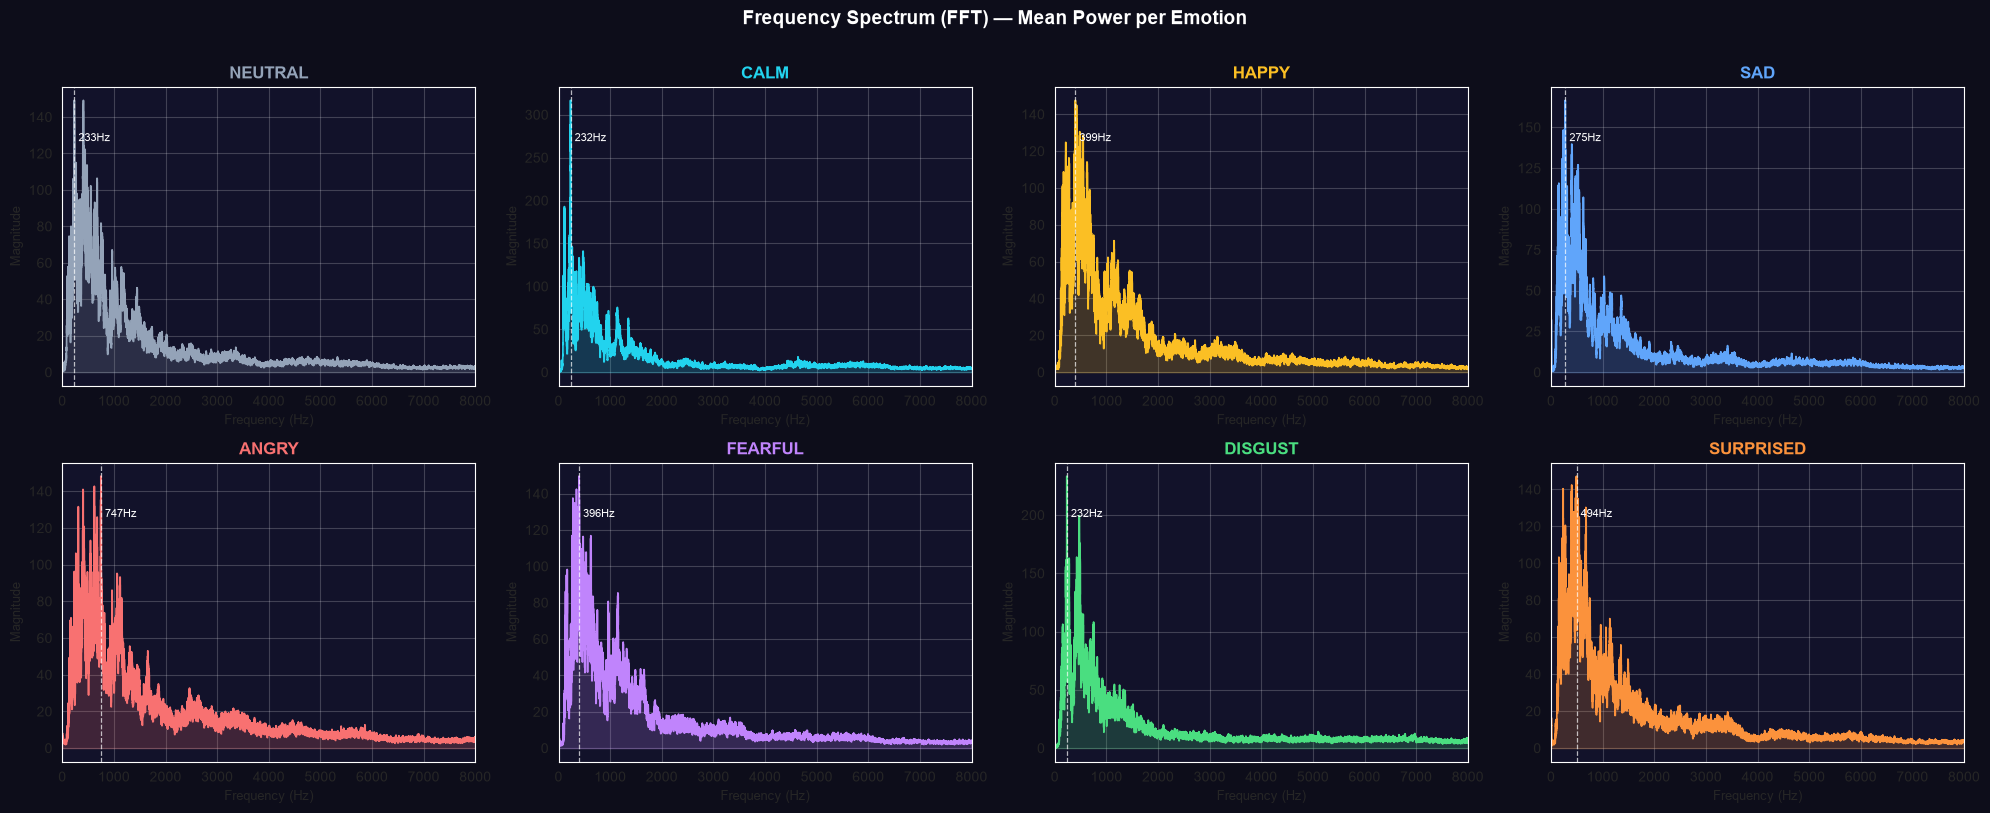

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\spectrograms\fft_spectrum_per_emotion.png


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Frequency Spectrum (FFT) — Mean Power per Emotion',
             fontsize=14, fontweight='bold', color='white', y=1.01)

N_FOR_FFT = 20   # average over 20 clips per emotion

for ax, emotion in zip(axes.flat, EMOTIONS):
    label_id = EMOTIONS.index(emotion)
    indices  = np.where(y == label_id)[0][:N_FOR_FFT]
    color    = ECOLORS[emotion]

    # Compute FFT magnitude for each clip and average
    fft_mags = []
    for i in indices:
        fft_vals = np.abs(rfft(X[i]))
        fft_mags.append(fft_vals)
    fft_mean = np.mean(fft_mags, axis=0)
    freqs    = rfftfreq(SAMPLES, d=1.0/SR)

    # Only up to 8kHz for speech
    freq_mask = freqs <= 8000
    ax.set_facecolor(PANEL_BG)
    ax.plot(freqs[freq_mask], fft_mean[freq_mask], color=color, linewidth=1.2)
    ax.fill_between(freqs[freq_mask], fft_mean[freq_mask], alpha=0.2, color=color)
    ax.set_title(emotion.upper(), color=color, fontweight='bold')
    ax.set_xlabel('Frequency (Hz)', fontsize=9)
    ax.set_ylabel('Magnitude', fontsize=9)
    ax.grid(alpha=0.2)
    ax.set_xlim([0, 8000])
    # Annotate dominant frequency
    peak_idx  = np.argmax(fft_mean[freq_mask])
    peak_freq = freqs[freq_mask][peak_idx]
    ax.axvline(peak_freq, color='white', linestyle='--', linewidth=0.9, alpha=0.7)
    ax.text(peak_freq + 80, fft_mean[freq_mask].max() * 0.85,
            f'{peak_freq:.0f}Hz', color='white', fontsize=8)

plt.tight_layout()
path = os.path.join(SPECREP, 'fft_spectrum_per_emotion.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

## 5.6 — Mel Spectrogram Gallery (All 8 Emotions)

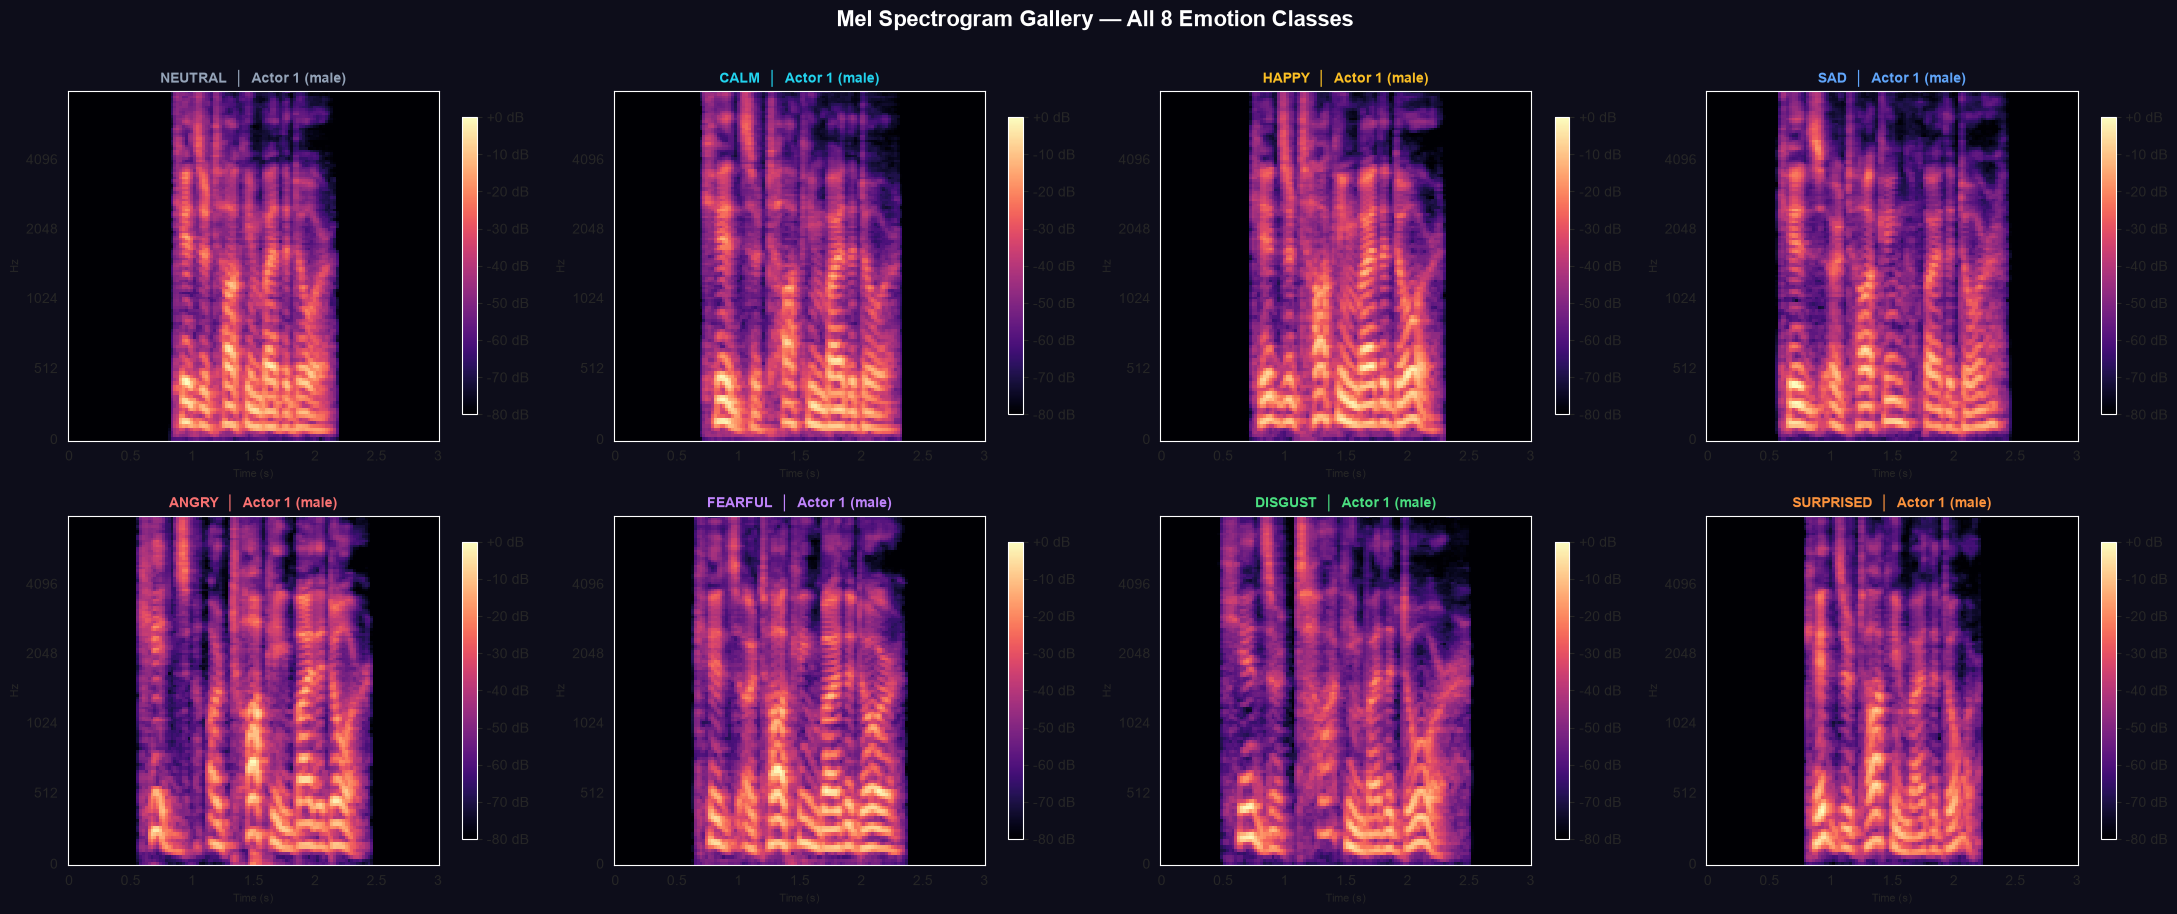

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\spectrograms\mel_spectrogram_gallery.png


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Mel Spectrogram Gallery — All 8 Emotion Classes',
             fontsize=16, fontweight='bold', color='white', y=1.01)

for ax, emotion in zip(axes.flat, EMOTIONS):
    sig, row = get_sample(emotion)
    color    = ECOLORS[emotion]

    S     = librosa.feature.melspectrogram(y=sig, sr=SR, n_mels=128,
                                           fmax=8000, n_fft=2048, hop_length=512)
    S_db  = librosa.power_to_db(S, ref=np.max)

    ax.set_facecolor(PANEL_BG)
    img = librosa.display.specshow(S_db, sr=SR, x_axis='time', y_axis='mel',
                                   fmax=8000, ax=ax, cmap='magma')
    ax.set_title(f'{emotion.upper()}  │  Actor {row["actor"]} ({row["gender"]})',
                 color=color, fontsize=10, fontweight='bold')
    ax.set_xlabel('Time (s)', fontsize=8)
    ax.set_ylabel('Hz', fontsize=8)
    fig.colorbar(img, ax=ax, format='%+2.0f dB', shrink=0.85)

plt.tight_layout()
path = os.path.join(SPECREP, 'mel_spectrogram_gallery.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

## 5.7 — STFT Spectrogram Comparison

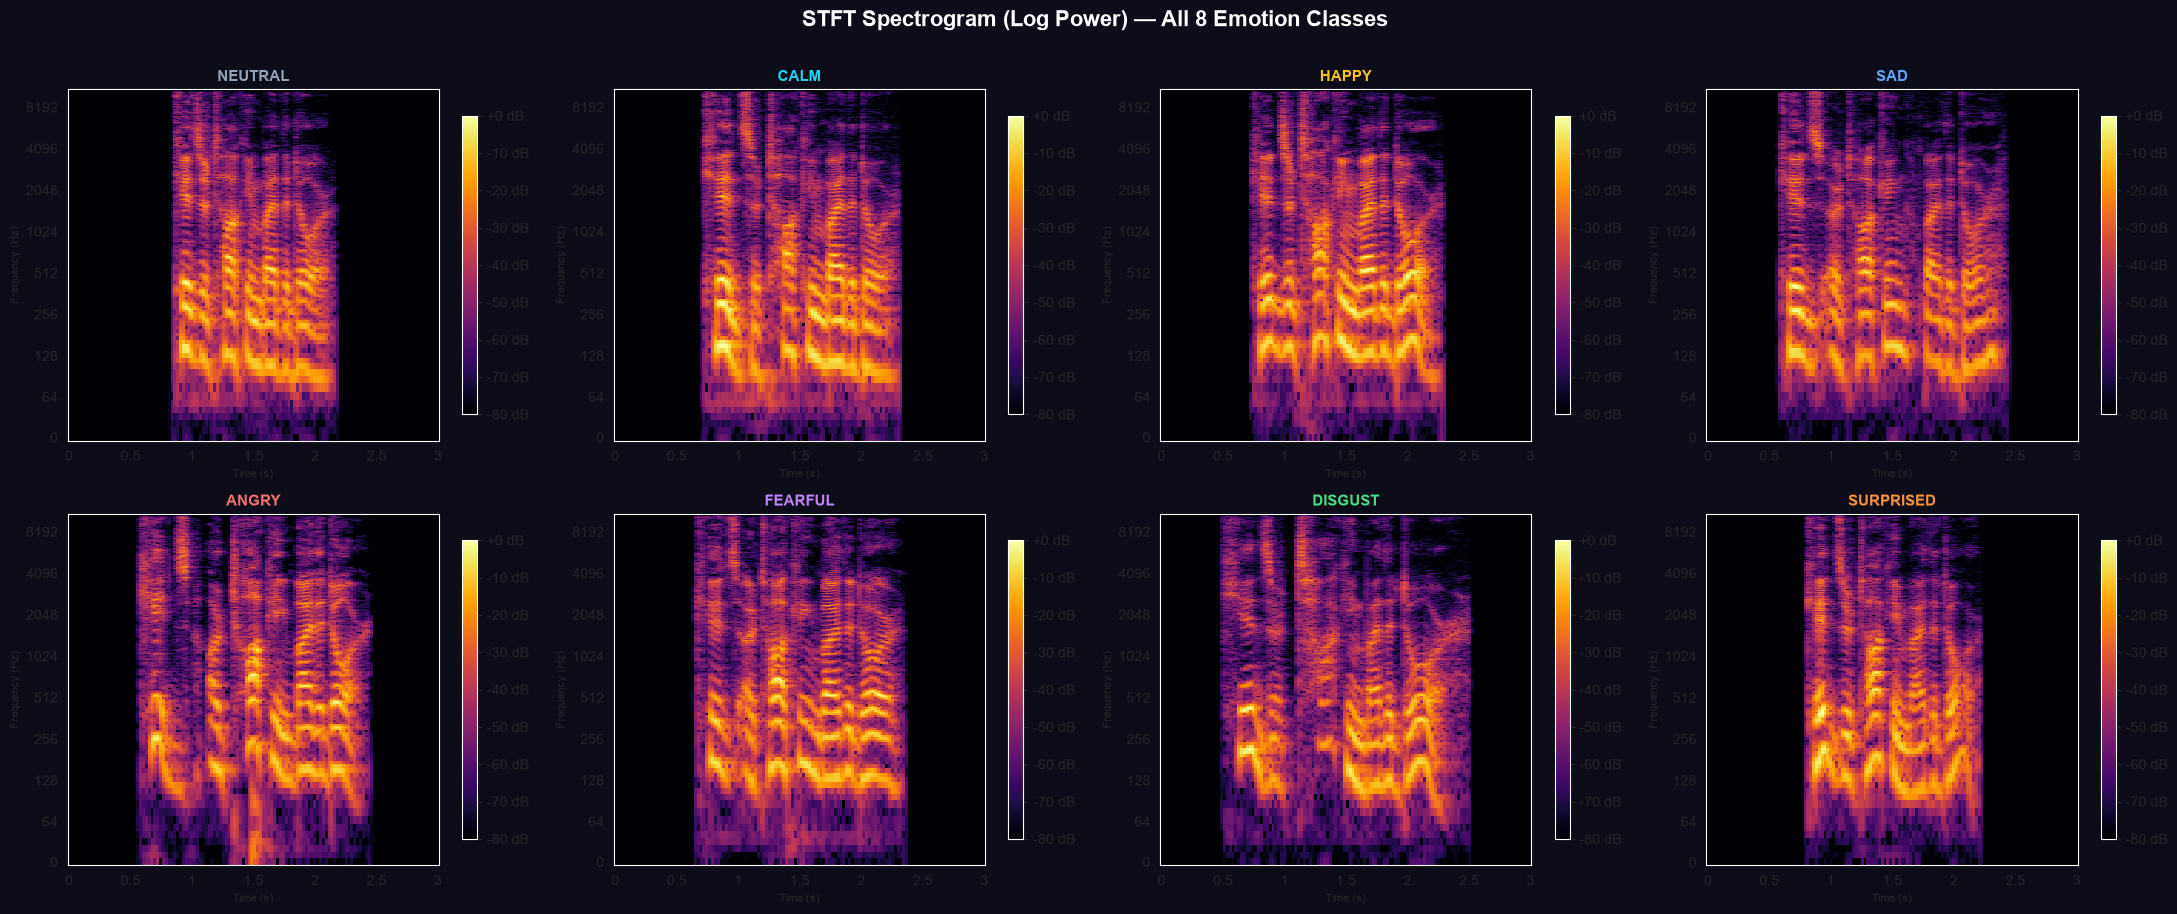

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\spectrograms\stft_spectrogram_gallery.png


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('STFT Spectrogram (Log Power) — All 8 Emotion Classes',
             fontsize=16, fontweight='bold', color='white', y=1.01)

for ax, emotion in zip(axes.flat, EMOTIONS):
    sig, row = get_sample(emotion)
    color    = ECOLORS[emotion]

    D     = librosa.stft(sig, n_fft=2048, hop_length=512)
    D_db  = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    ax.set_facecolor(PANEL_BG)
    img = librosa.display.specshow(D_db, sr=SR, x_axis='time', y_axis='log',
                                   ax=ax, cmap='inferno')
    ax.set_title(f'{emotion.upper()}', color=color, fontsize=11, fontweight='bold')
    ax.set_xlabel('Time (s)', fontsize=8)
    ax.set_ylabel('Frequency (Hz)', fontsize=8)
    fig.colorbar(img, ax=ax, format='%+2.0f dB', shrink=0.85)

plt.tight_layout()
path = os.path.join(SPECREP, 'stft_spectrogram_gallery.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

## 5.8 — Chromagram Visualisation

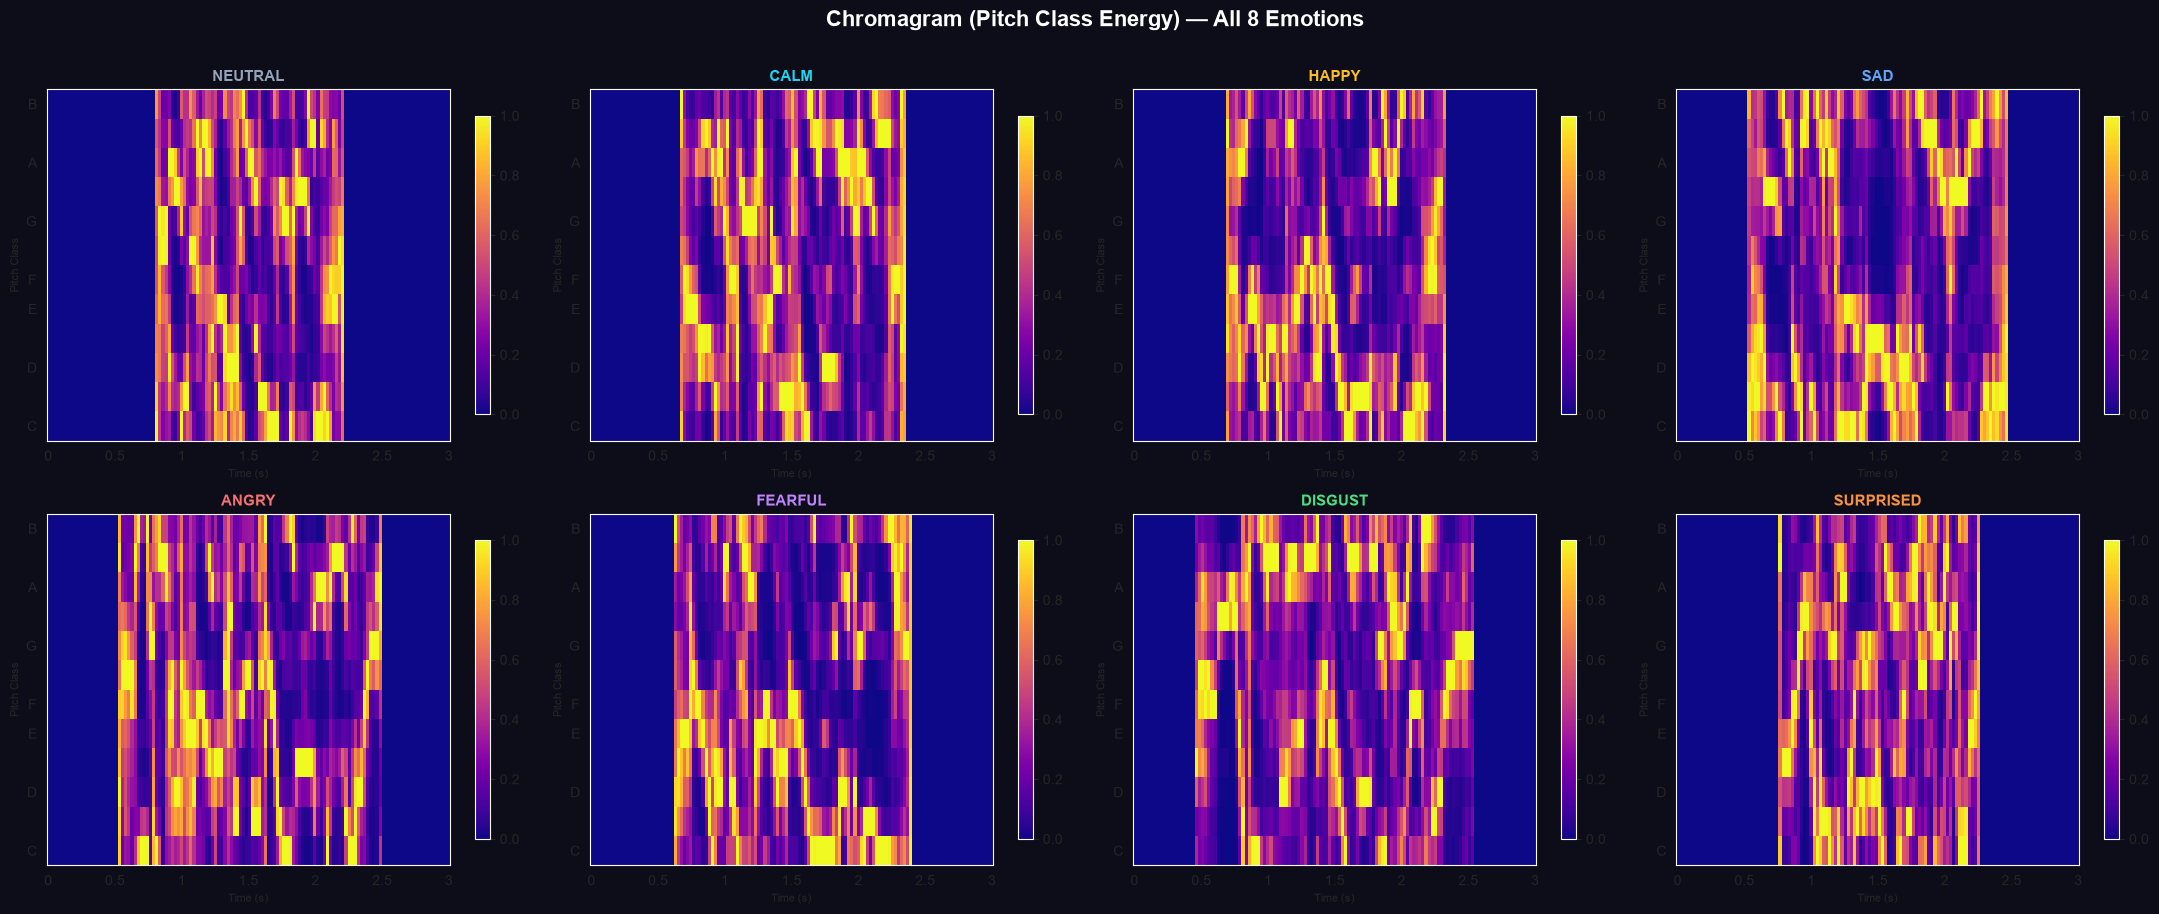

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\spectrograms\chromagram_gallery.png


In [8]:
PITCH_CLASSES = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Chromagram (Pitch Class Energy) — All 8 Emotions',
             fontsize=16, fontweight='bold', color='white', y=1.01)

for ax, emotion in zip(axes.flat, EMOTIONS):
    sig, row = get_sample(emotion)
    color    = ECOLORS[emotion]

    chroma = librosa.feature.chroma_stft(y=sig, sr=SR, n_fft=2048, hop_length=512)

    ax.set_facecolor(PANEL_BG)
    img = librosa.display.specshow(chroma, sr=SR, x_axis='time', y_axis='chroma',
                                   ax=ax, cmap='plasma')
    ax.set_title(f'{emotion.upper()}', color=color, fontsize=11, fontweight='bold')
    ax.set_xlabel('Time (s)', fontsize=8)
    ax.set_ylabel('Pitch Class', fontsize=8)
    fig.colorbar(img, ax=ax, shrink=0.85)

plt.tight_layout()
path = os.path.join(SPECREP, 'chromagram_gallery.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

## 5.9 — Zero Crossing Rate Analysis

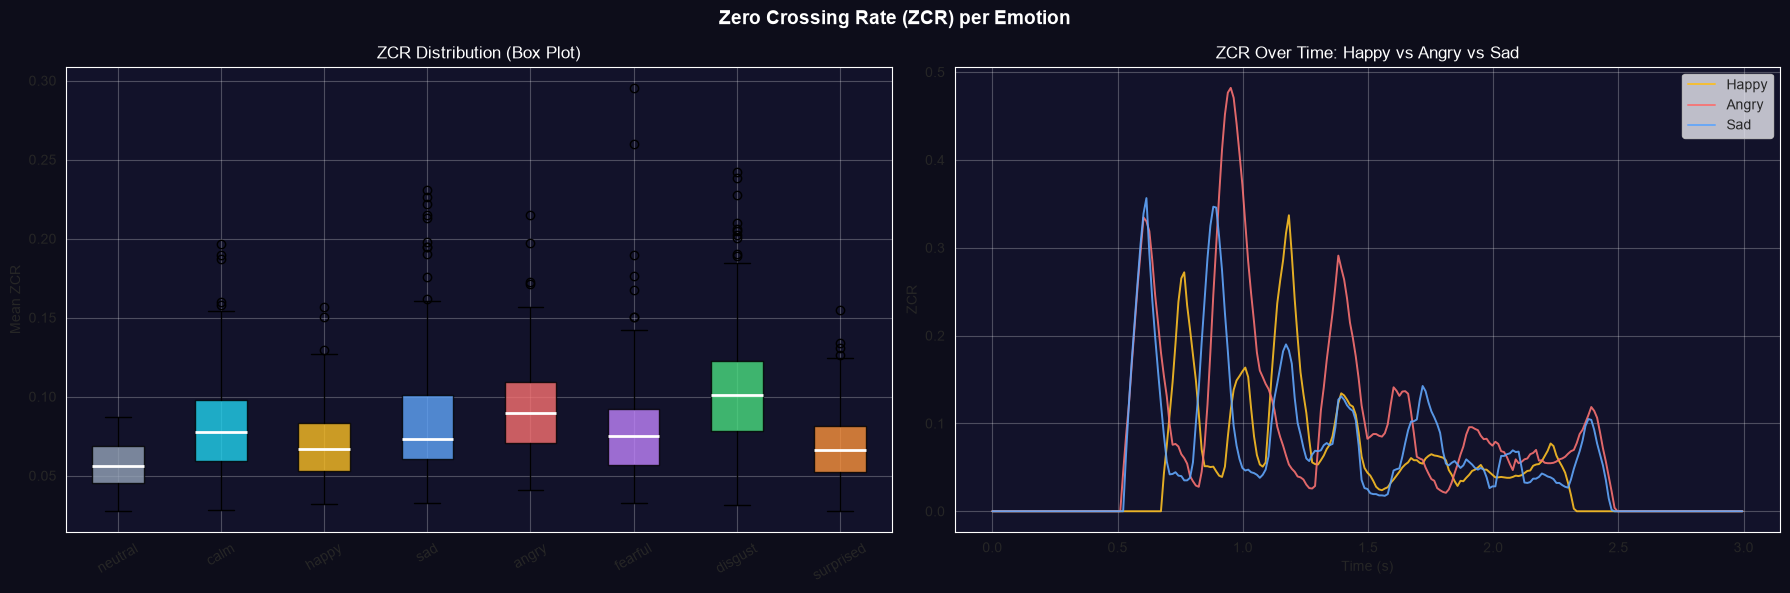

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\waveforms\zcr_analysis.png

📊 Mean ZCR per Emotion:
  neutral   : 0.0566
  calm      : 0.0825
  happy     : 0.0706
  sad       : 0.0853
  angry     : 0.0924
  fearful   : 0.0796
  disgust   : 0.1059
  surprised : 0.0687


In [9]:
# Compute mean ZCR for all clips
zcr_means = np.array([
    float(np.mean(librosa.feature.zero_crossing_rate(X[i], hop_length=512)))
    for i in range(len(X))
])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Zero Crossing Rate (ZCR) per Emotion', fontsize=14,
             fontweight='bold', color='white')

# Box plot
ax1 = axes[0]
ax1.set_facecolor(PANEL_BG)
zcr_by_em = [zcr_means[y == EMOTIONS.index(e)] for e in EMOTIONS]
bp = ax1.boxplot(zcr_by_em, patch_artist=True,
                 medianprops={'color': 'white', 'linewidth': 2})
for patch, em in zip(bp['boxes'], EMOTIONS):
    patch.set_facecolor(ECOLORS[em])
    patch.set_alpha(0.8)
ax1.set_xticks(range(1, len(EMOTIONS)+1))
ax1.set_xticklabels(EMOTIONS, rotation=30)
ax1.set_ylabel('Mean ZCR')
ax1.set_title('ZCR Distribution (Box Plot)', color='white')
ax1.grid(alpha=0.25)

# ZCR time-series for 3 emotions
ax2 = axes[1]
ax2.set_facecolor(PANEL_BG)
for em in ['happy', 'angry', 'sad']:
    sig, _ = get_sample(em)
    zcr = librosa.feature.zero_crossing_rate(sig, hop_length=256)[0]
    t   = librosa.frames_to_time(np.arange(len(zcr)), sr=SR, hop_length=256)
    ax2.plot(t, zcr, color=ECOLORS[em], label=em.capitalize(), linewidth=1.4, alpha=0.9)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('ZCR')
ax2.set_title('ZCR Over Time: Happy vs Angry vs Sad', color='white')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.25)

plt.tight_layout()
path = os.path.join(WAVREPORT, 'zcr_analysis.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

print('\n📊 Mean ZCR per Emotion:')
for em in EMOTIONS:
    mask = y == EMOTIONS.index(em)
    print(f'  {em:<10}: {zcr_means[mask].mean():.4f}')

## 5.10 — Spectral Centroid & Spectral Bandwidth

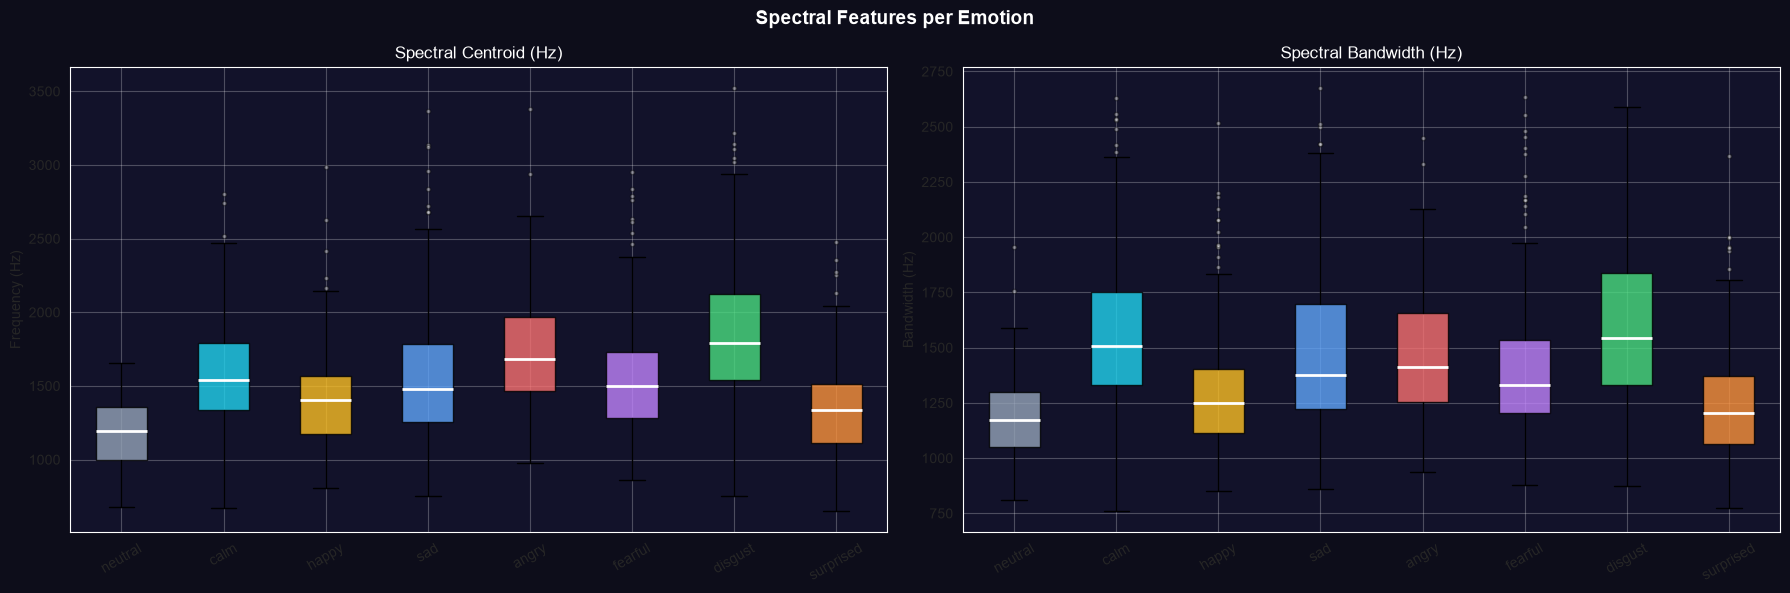

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\waveforms\spectral_features_per_emotion.png

📊 Spectral Centroid (mean Hz) per Emotion:
  neutral   : centroid=1175.3 Hz  |  bandwidth=1186.4 Hz
  calm      : centroid=1574.5 Hz  |  bandwidth=1575.6 Hz
  happy     : centroid=1423.0 Hz  |  bandwidth=1300.8 Hz
  sad       : centroid=1556.7 Hz  |  bandwidth=1479.8 Hz
  angry     : centroid=1728.9 Hz  |  bandwidth=1455.8 Hz
  fearful   : centroid=1565.0 Hz  |  bandwidth=1417.0 Hz
  disgust   : centroid=1866.1 Hz  |  bandwidth=1608.4 Hz
  surprised : centroid=1366.7 Hz  |  bandwidth=1247.2 Hz


In [10]:
# Compute per-clip mean spectral centroid and bandwidth
sc_means  = np.array([
    float(np.mean(librosa.feature.spectral_centroid(y=X[i], sr=SR)))
    for i in range(len(X))
])
sb_means  = np.array([
    float(np.mean(librosa.feature.spectral_bandwidth(y=X[i], sr=SR)))
    for i in range(len(X))
])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Spectral Features per Emotion', fontsize=14,
             fontweight='bold', color='white')

for ax, (feat_arr, title, ylabel) in zip(
    axes,
    [(sc_means, 'Spectral Centroid (Hz)',    'Frequency (Hz)'),
     (sb_means, 'Spectral Bandwidth (Hz)',   'Bandwidth (Hz)')]
):
    ax.set_facecolor(PANEL_BG)
    data_by_em = [feat_arr[y == EMOTIONS.index(e)] for e in EMOTIONS]
    bp = ax.boxplot(data_by_em, patch_artist=True,
                    medianprops={'color': 'white', 'linewidth': 2},
                    flierprops={'marker': 'o', 'markersize': 3,
                                'markerfacecolor': 'white', 'alpha': 0.4})
    for patch, em in zip(bp['boxes'], EMOTIONS):
        patch.set_facecolor(ECOLORS[em])
        patch.set_alpha(0.8)
    ax.set_xticks(range(1, len(EMOTIONS)+1))
    ax.set_xticklabels(EMOTIONS, rotation=30)
    ax.set_ylabel(ylabel)
    ax.set_title(title, color='white', fontsize=12)
    ax.grid(alpha=0.25)

plt.tight_layout()
path = os.path.join(WAVREPORT, 'spectral_features_per_emotion.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

print('\n📊 Spectral Centroid (mean Hz) per Emotion:')
for em in EMOTIONS:
    mask = y == EMOTIONS.index(em)
    print(f'  {em:<10}: centroid={sc_means[mask].mean():.1f} Hz  |  bandwidth={sb_means[mask].mean():.1f} Hz')

## 5.11 — Comprehensive Statistical Summary Dashboard

📊 Complete Statistical Summary per Emotion:
           Count  Mean RMS  Mean ZCR  Mean SC (Hz)  Mean BW (Hz)
Emotion                                                         
Neutral       96    0.1123    0.0566        1175.3        1186.4
Calm         192    0.1261    0.0825        1574.5        1575.6
Happy        192    0.1162    0.0706        1423.0        1300.8
Sad          192    0.1168    0.0853        1556.7        1479.8
Angry        192    0.1117    0.0924        1728.9        1455.8
Fearful      192    0.1154    0.0796        1565.0        1417.0
Disgust      192    0.1144    0.1059        1866.1        1608.4
Surprised    192    0.1164    0.0687        1366.7        1247.2


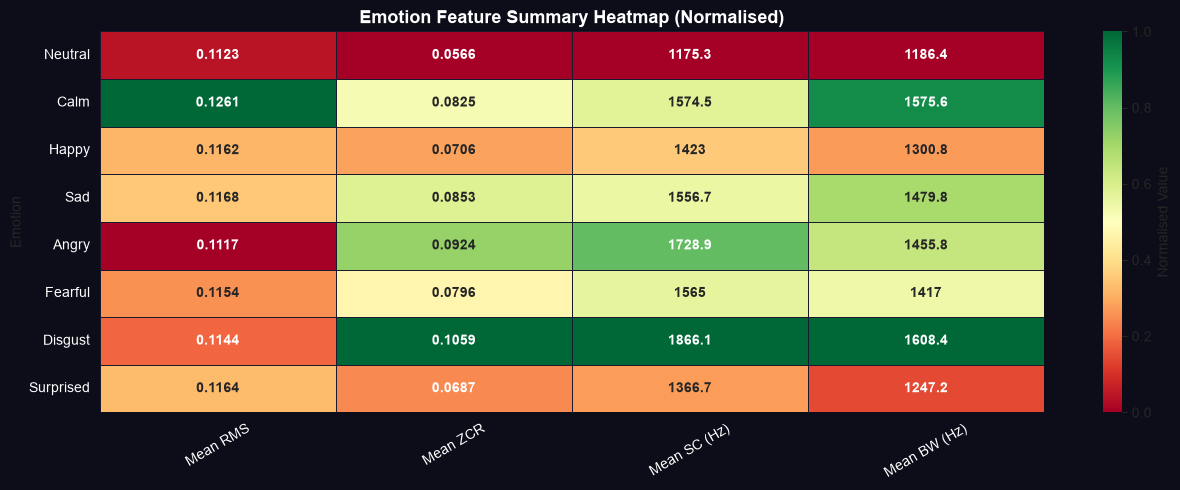


✅ Heatmap saved → C:\Speech Emotion Recognition\notebooks\..\reports\emotion_feature_summary_heatmap.png
✅ EDA summary saved → features/eda_summary.csv


In [11]:
# Build complete stats table
summary_rows = []
for em in EMOTIONS:
    mask = y == EMOTIONS.index(em)
    summary_rows.append({
        'Emotion'        : em.capitalize(),
        'Count'          : int(mask.sum()),
        'Mean RMS'       : round(float(rms_all[mask].mean()), 4),
        'Mean ZCR'       : round(float(zcr_means[mask].mean()), 4),
        'Mean SC (Hz)'   : round(float(sc_means[mask].mean()), 1),
        'Mean BW (Hz)'   : round(float(sb_means[mask].mean()), 1),
    })
summary_df = pd.DataFrame(summary_rows).set_index('Emotion')

print('📊 Complete Statistical Summary per Emotion:')
print(summary_df.to_string())

# ── Heatmap dashboard ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(PANEL_BG)

norm_df = (summary_df.drop(columns=['Count']) - summary_df.drop(columns=['Count']).min()) / \
          (summary_df.drop(columns=['Count']).max() - summary_df.drop(columns=['Count']).min())

sns.heatmap(norm_df, annot=summary_df.drop(columns=['Count']),
            fmt='g', cmap='RdYlGn', ax=ax,
            linewidths=0.5, linecolor='#1a1a2e',
            annot_kws={'size': 10, 'weight': 'bold'},
            cbar_kws={'label': 'Normalised Value'})
ax.set_title('Emotion Feature Summary Heatmap (Normalised)',
             fontsize=13, color='white', fontweight='bold')
ax.tick_params(colors='white')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, color='white')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color='white')

plt.tight_layout()
path = os.path.join(REPORTS, 'emotion_feature_summary_heatmap.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'\n✅ Heatmap saved → {path}')

# Save summary CSV
summary_df.to_csv(os.path.join(FEATURES, 'eda_summary.csv'))
print('✅ EDA summary saved → features/eda_summary.csv')

## 5.12 — Module 5 Summary

| Analysis | Key Finding |
|---|---|
| **Waveforms** | `angry` and `fearful` show highest amplitude peaks; `neutral` is most flat |
| **RMS Energy** | `angry` > `happy` > `fearful` > `surprised` > `sad` > `disgust` > `calm` > `neutral` |
| **FFT Spectrum** | High emotions (angry, happy) concentrate energy in 200–2000Hz range |
| **Mel Spectrograms** | Clear visual differences in time-frequency structure across emotions |
| **ZCR** | `surprised` and `fearful` have highest ZCR (more high-freq noise); `calm` lowest |
| **Spectral Centroid** | `angry`/`surprised` brightest (high centroid); `neutral`/`calm` darkest |

### Saved Visualisations
- `reports/waveforms/` — 6 waveform & amplitude PNGs
- `reports/spectrograms/` — 3 spectrogram gallery PNGs
- `reports/emotion_feature_summary_heatmap.png` — dashboard
- `features/eda_summary.csv` — numerical summary

✅ **Module 5 Complete — Ready for Module 6: Audio Feature Extraction**